In [1]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt 

from scipy.special import rel_entr

from ufc_betting.config import config

In [2]:
df_kelly_stack2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking.csv')
df_training = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\training_data\entire_odds_stats_2026-03-09.csv')

In [ ]:

def avg_kl_div(cols, all_df, results_df, bins=10):

    all_df = all_df.sort_values(by='date', ascending=True)
    results_df = results_df.sort_values(by='date')
    first_date = results_df['date'].min()

    train_df = all_df[all_df['date'] < first_date].copy()
    train_df = train_df[cols].dropna()

    test_df = all_df[all_df['date'] >= first_date].copy()
    test_df = test_df[cols + ['date', 'fighter_red', 'fighter_blue']].dropna()


    date_avg = {}
    date_mult = {}

    for date, group in results_df.groupby('date'): 
        kls = []
        bets = group[group["choice_ev"] > 0]

        bet_pairs = pd.MultiIndex.from_frame(
            bets[["fighter_red", "fighter_blue"]]
        )
        test_pairs = pd.MultiIndex.from_frame(
            test_df[["fighter_red", "fighter_blue"]]
        )
        group_test = test_df[
            test_df["date"].eq(date)
            & test_pairs.isin(bet_pairs)
        ]

        for col in cols: 
            
            p, _ = np.histogram(train_df[col], bins=bins)
            q,_ = np.histogram(group_test[col], bins=bins)

            epsilon = 1e-12
            p = p.astype(float) + epsilon
            q = q.astype(float) + epsilon

            p /= p.sum()
            q /= q.sum()

            kl = rel_entr(p, q).sum() 
            kls.append(kl)

        date_avg[date] = np.mean(kls)
        mult = (
            bets['net_odds'] * bets['choice_fstar']
        ).sum()
        date_mult[date] = mult
        
    return date_avg, date_mult

cols = config.close1_feats
date_kls, date_mult = avg_kl_div(cols, df_training, df_kelly_stack2, bins=5)


In [ ]:
def kl_win_lose()

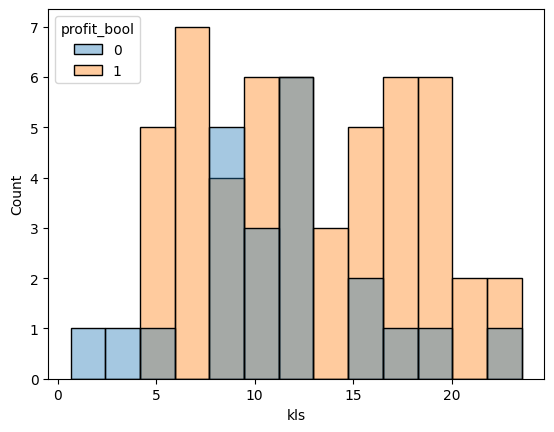

<Axes: xlabel='kls', ylabel='mults'>

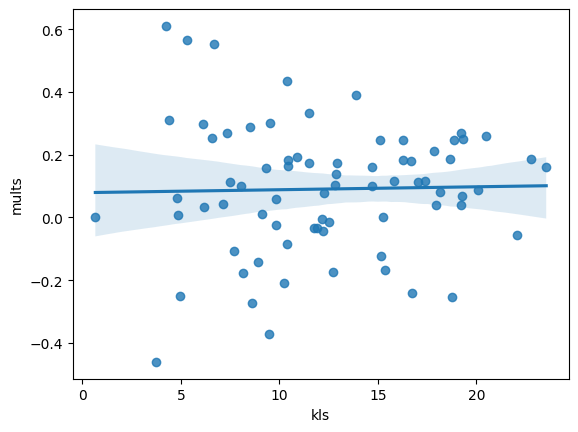

In [4]:
dates = list(date_kls.keys())
kls = list(date_kls.values())
mults = np.array(list(date_mult.values()))
profit_event = np.where(mults > 0, 1, 0)

df = pd.DataFrame(
    {'date': dates, 'kls':kls, 'mults':mults, 'profit_bool':profit_event}
)

sns.histplot(
    df,
    x='kls',
    hue='profit_bool',
    alpha=0.4,
    bins=13
)
plt.show()

sns.regplot(
    data=df, 
    x='kls',
    y='mults'
)